In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

hour = pd.read_csv("hour.csv")
day = pd.read_csv("day.csv")

In [2]:
hour = hour.drop(columns=["instant", "dteday", "yr", "casual", "registered"])
day = day.drop(columns=["instant", "dteday", "yr", "casual", "registered"])
print("Hour dataset after dropping columns:")
print(hour.head().to_string(index=False))

print("\nDay dataset after dropping columns:")
print(day.head().to_string(index=False))


Hour dataset after dropping columns:
 season  mnth  hr  holiday  weekday  workingday  weathersit  temp  atemp  hum  windspeed  cnt
      1     1   0        0        6           0           1  0.24 0.2879 0.81        0.0   16
      1     1   1        0        6           0           1  0.22 0.2727 0.80        0.0   40
      1     1   2        0        6           0           1  0.22 0.2727 0.80        0.0   32
      1     1   3        0        6           0           1  0.24 0.2879 0.75        0.0   13
      1     1   4        0        6           0           1  0.24 0.2879 0.75        0.0    1

Day dataset after dropping columns:
 season  mnth  holiday  weekday  workingday  weathersit     temp    atemp      hum  windspeed  cnt
      1     1        0        6           0           2 0.344167 0.363625 0.805833   0.160446  985
      1     1        0        0           0           2 0.363478 0.353739 0.696087   0.248539  801
      1     1        0        1           1           1 0.196364 

In [3]:
hour.isnull().sum()



season        0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

In [4]:
day.isnull().sum()

season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

In [5]:
hour_duplicates = hour.duplicated().sum()
day_duplicates = day.duplicated().sum()
print("Number of duplicate hours:", hour_duplicates)
print("Number of duplicate days:", day_duplicates)




Number of duplicate hours: 2
Number of duplicate days: 0


In [6]:
hour = hour.drop_duplicates() 
print("Hour dataset after dropping duplicates:")
print(hour.head().to_string(index=False))


Hour dataset after dropping duplicates:
 season  mnth  hr  holiday  weekday  workingday  weathersit  temp  atemp  hum  windspeed  cnt
      1     1   0        0        6           0           1  0.24 0.2879 0.81        0.0   16
      1     1   1        0        6           0           1  0.22 0.2727 0.80        0.0   40
      1     1   2        0        6           0           1  0.22 0.2727 0.80        0.0   32
      1     1   3        0        6           0           1  0.24 0.2879 0.75        0.0   13
      1     1   4        0        6           0           1  0.24 0.2879 0.75        0.0    1


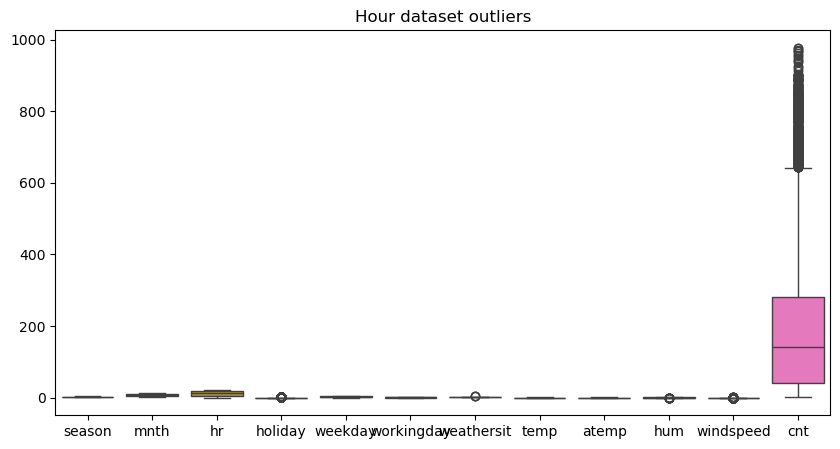

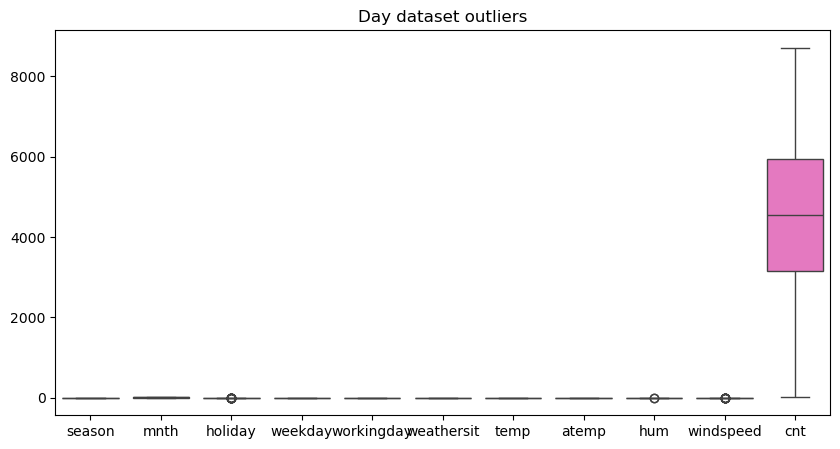

In [7]:
plt.figure(figsize=(10,5))
sns.boxplot(data=hour)
plt.title("Hour dataset outliers")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=day)
plt.title("Day dataset outliers")
plt.show()


In [8]:
# ---- Outlier Detection for Hour Data ----
Q1_hr = hour.quantile(0.25)
Q3_hr = hour.quantile(0.75)
IQR_hr = Q3_hr - Q1_hr

lower_limit_hr = Q1_hr - 1.5 * IQR_hr
upper_limit_hr = Q3_hr + 1.5 * IQR_hr

hour_cleaned = hour[~((hour < lower_limit_hr) | (hour > upper_limit_hr)).any(axis=1)]

print("Original Hour Shape:", hour.shape)
print("After Removing Outliers:", hour_cleaned.shape)

Original Hour Shape: (17377, 12)
After Removing Outliers: (16027, 12)


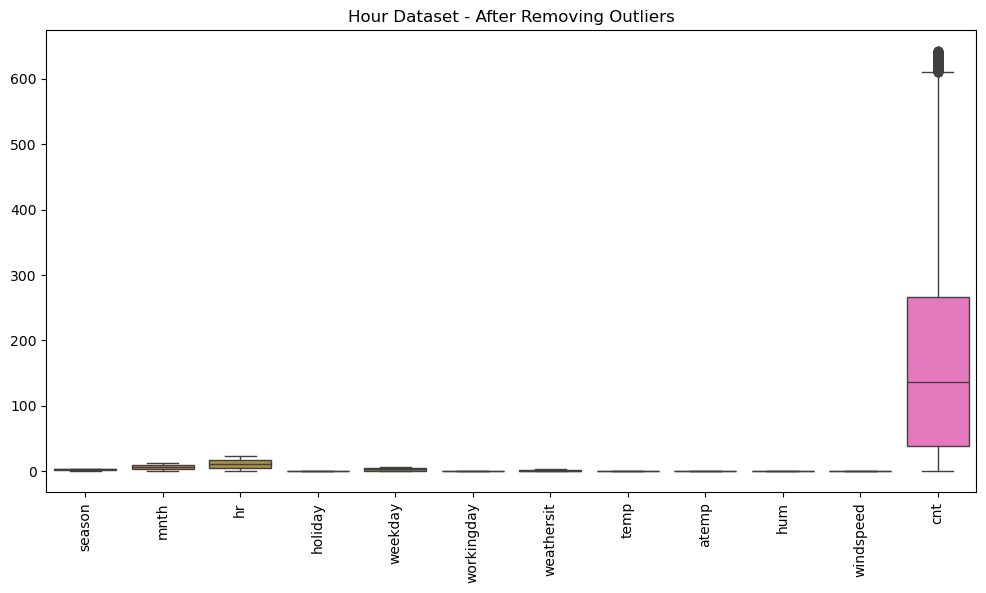

In [9]:
# ---- Boxplot after removing outliers ----
plt.figure(figsize=(12,6))
sns.boxplot(data=hour_cleaned)
plt.title("Hour Dataset - After Removing Outliers")
plt.xticks(rotation=90)
plt.show()

In [10]:
# ---- Outlier Detection for Day Data ----
Q1 = day.quantile(0.25)
Q3 = day.quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

day_cleaned = day[~((day < lower_limit) | (day > upper_limit)).any(axis=1)]
print("Original Day Shape:", day.shape)
print("After Removing Outliers:", day_cleaned.shape)



Original Day Shape: (731, 11)
After Removing Outliers: (696, 11)


In [11]:
print("Null values per column (Hourly):")
print(hour.isnull().sum())

print("\nNull values per column (Daily):")
print(day.isnull().sum())

hour = hour.fillna(hour.median())
day = day.fillna(day.median())

print("After filling, nulls (Hourly):", hour.isnull().sum().sum())
print("After filling, nulls (Daily):", day.isnull().sum().sum())

Null values per column (Hourly):
season        0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

Null values per column (Daily):
season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64
After filling, nulls (Hourly): 0
After filling, nulls (Daily): 0


In [12]:
X_hour = hour.drop("cnt", axis=1)
y_hour = hour["cnt"]

X_day = day.drop("cnt", axis=1)
y_day = day["cnt"]

In [13]:
from sklearn.model_selection import train_test_split

# Hourly data train-test split
X_train_hr, X_test_hr, y_train_hr, y_test_hr = train_test_split(X_hour, y_hour, test_size=0.2, random_state=42)
# Daily data train-test split
X_train_day, X_test_day, y_train_day, y_test_day = train_test_split(X_day, y_day, test_size=0.2, random_state=42)

In [14]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def train_evaluate_rf(X_train, X_test, y_train, y_test, dataset_name="Dataset"):
    # Train Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    
    # Predict
    y_pred = rf.predict(X_test)
    
    # Evaluation Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
     
    print(f"{dataset_name} - Random Forest Metrics")
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}\n")
    return rf 
    


In [15]:
#Train & evaluate for both datasets
rf_hour = train_evaluate_rf(X_train_hr, X_test_hr, y_train_hr, y_test_hr, "Hourly Data")
rf_day  = train_evaluate_rf(X_train_day, X_test_day, y_train_day, y_test_day, "Daily Data")


Hourly Data - Random Forest Metrics
MAE: 42.88, RMSE: 64.90, R²: 0.86

Daily Data - Random Forest Metrics
MAE: 1083.93, RMSE: 1305.34, R²: 0.58



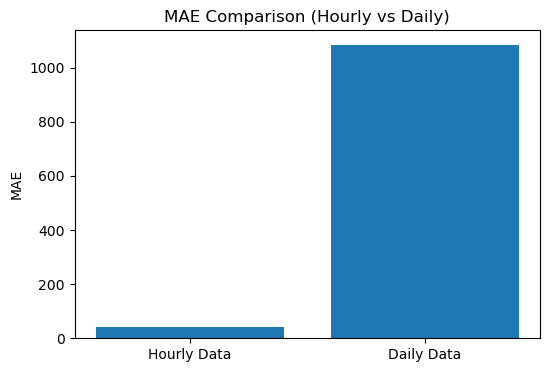

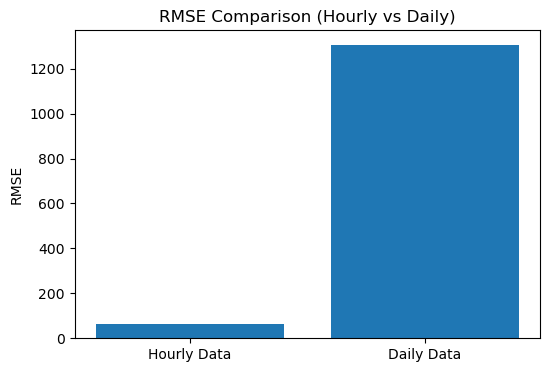

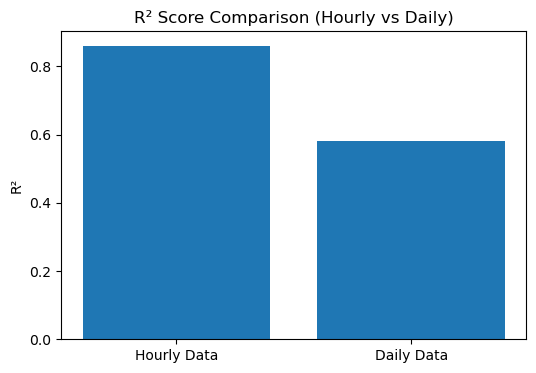

In [16]:
# ---- Metrics Comparison Graphs ----

import matplotlib.pyplot as plt

datasets = ["Hourly Data", "Daily Data"]
mae_values = [42.88, 1083.93]
rmse_values = [64.90, 1305.34]
r2_values = [0.86, 0.58]


# MAE Comparison
plt.figure(figsize=(6,4))
plt.bar(datasets, mae_values)
plt.title("MAE Comparison (Hourly vs Daily)")
plt.ylabel("MAE")
plt.show()

# RMSE Comparison
plt.figure(figsize=(6,4))
plt.bar(datasets, rmse_values)
plt.title("RMSE Comparison (Hourly vs Daily)")
plt.ylabel("RMSE")
plt.show()

# R² Comparison
plt.figure(figsize=(6,4))
plt.bar(datasets, r2_values)
plt.title("R² Score Comparison (Hourly vs Daily)")
plt.ylabel("R²")
plt.show()


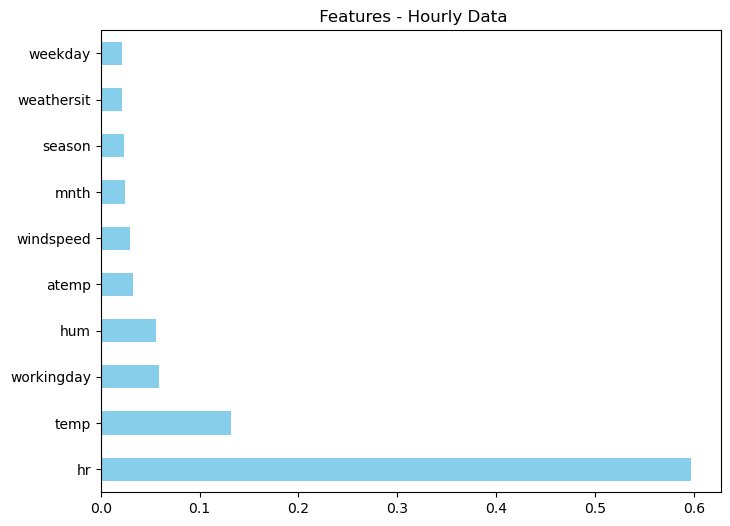

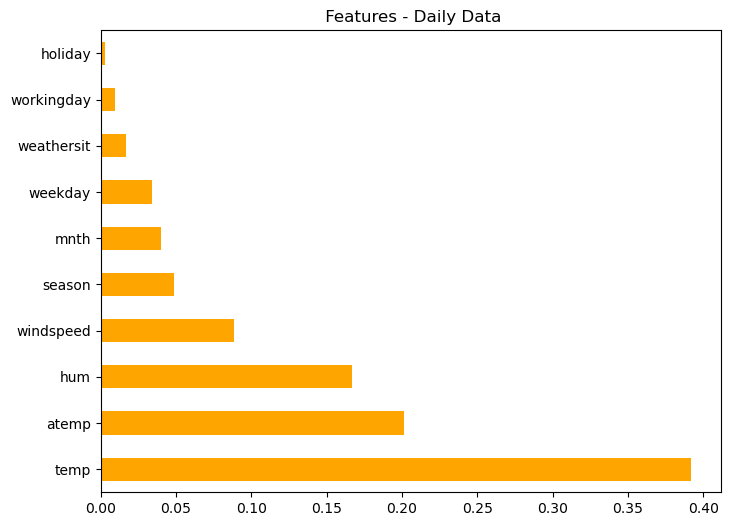

In [17]:
               # --- Feature Importance Plot ---
def plot_feature_importance(rf_model, X_train, dataset_name):
    feat_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
    plt.figure(figsize=(8,6))
    color = 'skyblue' if dataset_name=="Hourly Data" else 'orange'
    feat_importances.nlargest(10).plot(kind='barh', color=color)
    plt.title(f" Features - {dataset_name}")
    plt.show()

# Plot top 10 features for both datasets
plot_feature_importance(rf_hour, X_train_hr, "Hourly Data")
plot_feature_importance(rf_day, X_train_day, "Daily Data")

In [18]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [19]:

 def train_evaluate_models(X_train, X_test, y_train, y_test):
    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(random_state=42)
    }

    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results.append({
            "Model": name,
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "R2": r2_score(y_test, y_pred)
        })

    return pd.DataFrame(results)

   

In [20]:
# Hourly
hour_results = train_evaluate_models(
    X_train_hr, X_test_hr, y_train_hr, y_test_hr
)
print("Hourly Results")
display(hour_results)



Hourly Results


,Model,MAE,RMSE,R2
0,Linear Regression,105.720617,141.696994,0.345995
1,Decision Tree,53.935270,88.585113,0.744388
2,Random Forest,42.876734,64.900524,0.862799


In [21]:
# Daily
day_results = train_evaluate_models(
    X_train_day, X_test_day, y_train_day, y_test_day
)
print("Daily Results")
display(day_results)

Daily Results


,Model,MAE,RMSE,R2
0,Linear Regression,1143.393718,1340.514122,0.551863
1,Decision Tree,1248.163265,1644.848392,0.325285
2,Random Forest,1083.931088,1305.338730,0.575073


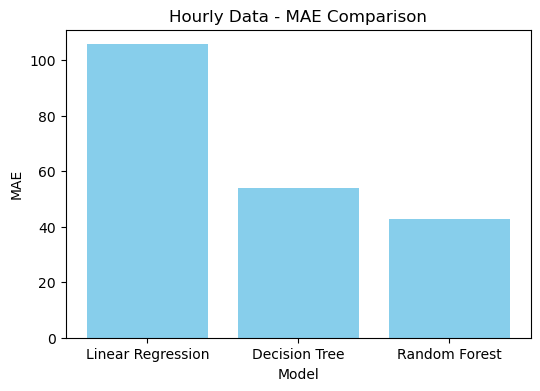

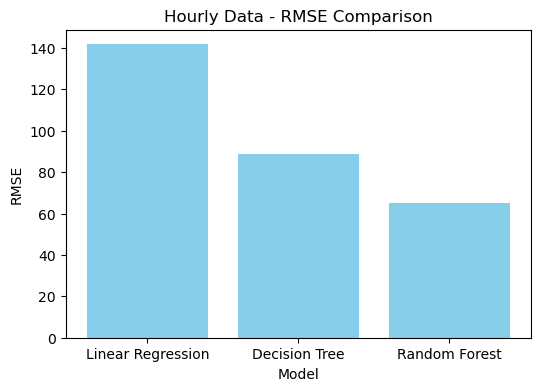

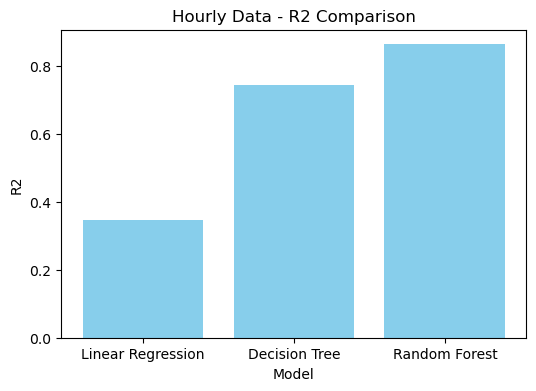

In [22]:
#Hourly Data Boxplot

metrics = ["MAE", "RMSE", "R2"]

for metric in metrics:
    plt.figure(figsize=(6,4))
    plt.bar(hour_results["Model"], hour_results[metric], color='skyblue')
    plt.title(f"Hourly Data - {metric} Comparison")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.show()







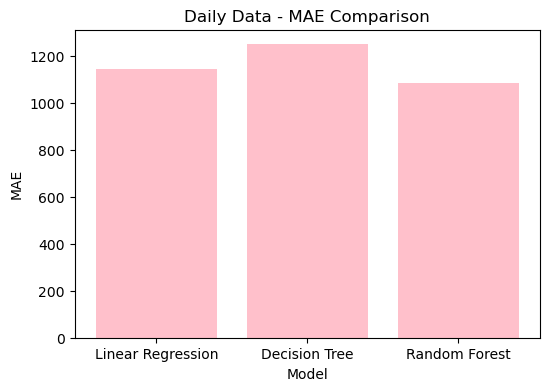

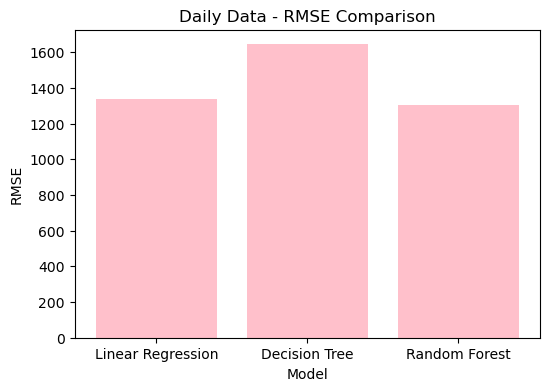

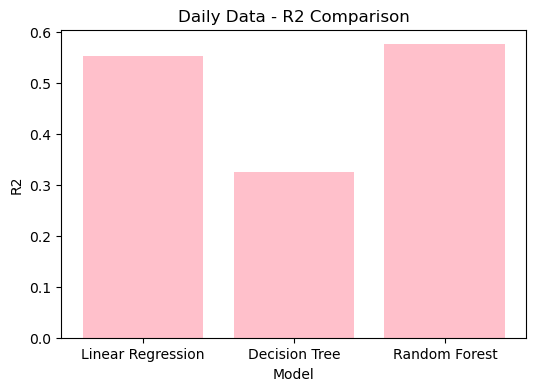

In [23]:
# Daily Data Boxplot
for metric in metrics:
    plt.figure(figsize=(6,4))
    plt.bar(day_results["Model"], day_results[metric], color='pink')
    plt.title(f"Daily Data - {metric} Comparison")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.show()


In [24]:
from sklearn.metrics import r2_score

models_hr = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

print("----- HOURLY DATA (TRAIN vs TEST) -----\n")

for name, model in models_hr.items():
    model.fit(X_train_hr, y_train_hr)
    
    train_pred = model.predict(X_train_hr)
    test_pred  = model.predict(X_test_hr)
    
    r2_train = r2_score(y_train_hr, train_pred)
    r2_test  = r2_score(y_test_hr, test_pred)
    
    print(f"{name}")
    print(f"Train R²: {r2_train:.2f}")
    print(f"Test  R²: {r2_test:.2f}")
    
    if r2_train < 0.6 and r2_test < 0.6:
        print("→ Underfitting\n")
    elif r2_train - r2_test > 0.15:
        print("→ Overfitting\n")
    else:
        print("→ Good Fit\n")






----- HOURLY DATA (TRAIN vs TEST) -----

Linear Regression
Train R²: 0.34
Test  R²: 0.35
→ Underfitting

Decision Tree
Train R²: 1.00
Test  R²: 0.74
→ Overfitting

Random Forest
Train R²: 0.98
Test  R²: 0.86
→ Good Fit



In [25]:
models_day = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

print("----- DAILY DATA (TRAIN vs TEST) -----\n")

for name, model in models_day.items():
    model.fit(X_train_day, y_train_day)
    
    train_pred = model.predict(X_train_day)
    test_pred  = model.predict(X_test_day)
    
    r2_train = r2_score(y_train_day, train_pred)
    r2_test  = r2_score(y_test_day, test_pred)
    
    print(f"{name}")
    print(f"Train R²: {r2_train:.2f}")
    print(f"Test  R²: {r2_test:.2f}")
    
    if r2_train < 0.6 and r2_test < 0.6:
        print("→ Underfitting\n")
    elif r2_train - r2_test > 0.15:
        print("→ Overfitting\n")
    else:
        print("→ Good Fit\n")


----- DAILY DATA (TRAIN vs TEST) -----

Linear Regression
Train R²: 0.52
Test  R²: 0.55
→ Underfitting

Decision Tree
Train R²: 1.00
Test  R²: 0.33
→ Overfitting

Random Forest
Train R²: 0.95
Test  R²: 0.58
→ Overfitting



In [26]:
# Hourly
hour_results_test = []

for name, model in models_hr.items():
    model.fit(X_train_hr, y_train_hr)
    train_pred = model.predict(X_train_hr)
    test_pred  = model.predict(X_test_hr)
    r2_train = r2_score(y_train_hr, train_pred)
    r2_test  = r2_score(y_test_hr, test_pred)
    
    hour_results_test.append({
        "Model": name,
        "Train_R2": r2_train,
        "Test_R2": r2_test
    })

hour_results_test = pd.DataFrame(hour_results_test)


In [27]:
# Daily
day_results_test = []

for name, model in models_day.items():
    model.fit(X_train_day, y_train_day)
    train_pred = model.predict(X_train_day)
    test_pred  = model.predict(X_test_day)
    r2_train = r2_score(y_train_day, train_pred)
    r2_test  = r2_score(y_test_day, test_pred)
    
    day_results_test.append({
        "Model": name,
        "Train_R2": r2_train,
        "Test_R2": r2_test
    })

day_results_test = pd.DataFrame(day_results_test)


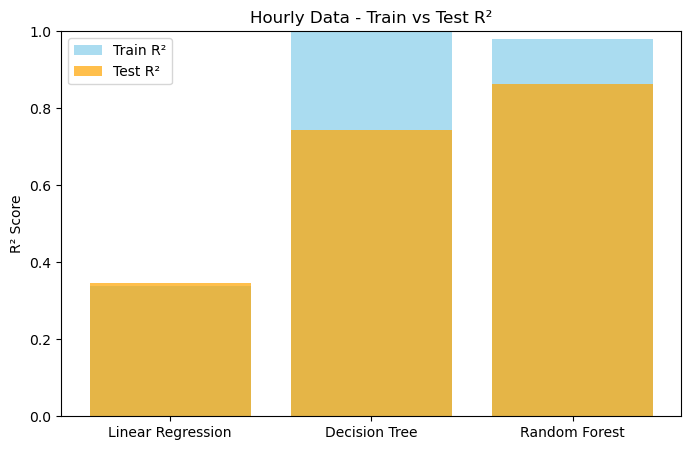

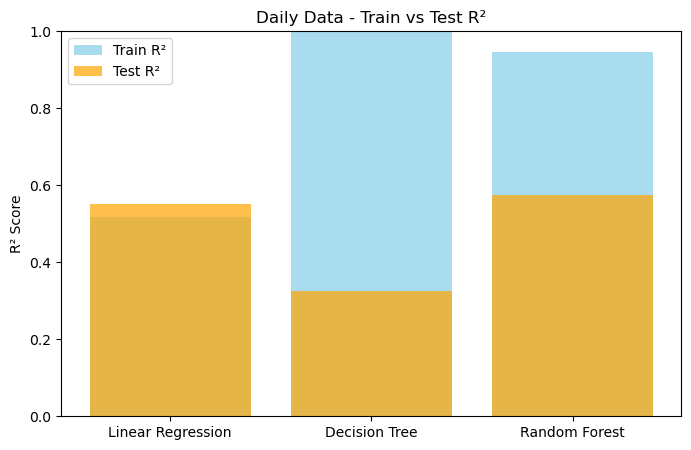

In [28]:

def plot_train_test_r2(df, dataset_name="Dataset"):
    plt.figure(figsize=(8,5))
    plt.bar(df['Model'], df['Train_R2'], alpha=0.7, label='Train R²', color='skyblue')
    plt.bar(df['Model'], df['Test_R2'], alpha=0.7, label='Test R²', color='orange')
    plt.title(f"{dataset_name} - Train vs Test R²")
    plt.ylabel("R² Score")
    plt.ylim(0, 1)
    plt.legend()
    plt.show()

# Hourly
plot_train_test_r2(hour_results_test, "Hourly Data")

# Daily
plot_train_test_r2(day_results_test, "Daily Data")


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



In [30]:
day = pd.read_csv("day.csv", parse_dates=['dteday']) 
day['year'] = day['dteday'].dt.year
day['month'] = day['dteday'].dt.month
day['day'] = day['dteday'].dt.day
day['weekday'] = day['dteday'].dt.weekday


In [31]:

features = ['year', 'month', 'day', 'weekday', 'temp', 'hum', 'windspeed'] 
target = 'cnt'

X = day[features]
y = day[target]


In [32]:
#Train-Test SPlit
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [33]:
#HyperParameter Tuning
rf_day = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=17,
    random_state=42,
    n_jobs=-1
)


In [34]:
# Training
rf_day.fit(X_train_scaled, y_train)
print("Trained Random Forest Model:")
print(rf_day)


Trained Random Forest Model:
RandomForestRegressor(max_depth=5, min_samples_leaf=17, min_samples_split=10,
                      n_estimators=300, n_jobs=-1, random_state=42)


In [35]:
#Test and train Predictions
y_train_pred = rf_day.predict(X_train_scaled)  # train predictions
y_test_pred  = rf_day.predict(X_test_scaled)   # test predictions



In [36]:
# Evaluation metrics
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

print(f"Training Data → MAE: {mae_train:.2f}, RMSE: {rmse_train:.2f}, R²: {r2_train:.2f}")
print(f"Test Data     → MAE: {mae_test:.2f}, RMSE: {rmse_test:.2f}, R²: {r2_test:.2f}")

Training Data → MAE: 569.62, RMSE: 757.38, R²: 0.84
Test Data     → MAE: 624.34, RMSE: 914.10, R²: 0.79


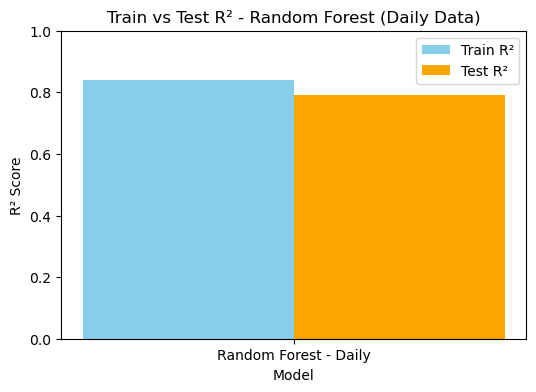

In [37]:
#bar chart
# Values
models = ['Random Forest - Daily']
train_r2 = [0.84]  # your training R²
test_r2  = [0.79]  # your test R²

# Plot
plt.figure(figsize=(6,4))
bar_width = 0.4
x = range(len(models))

plt.bar(x, train_r2, width=bar_width, label='Train R²', color='skyblue')
plt.bar([i + bar_width for i in x], test_r2, width=bar_width, label='Test R²', color='orange')

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Train vs Test R² - Random Forest (Daily Data)")
plt.xticks([i + bar_width/2 for i in x], models)
plt.ylim(0,1)
plt.legend()
plt.show()

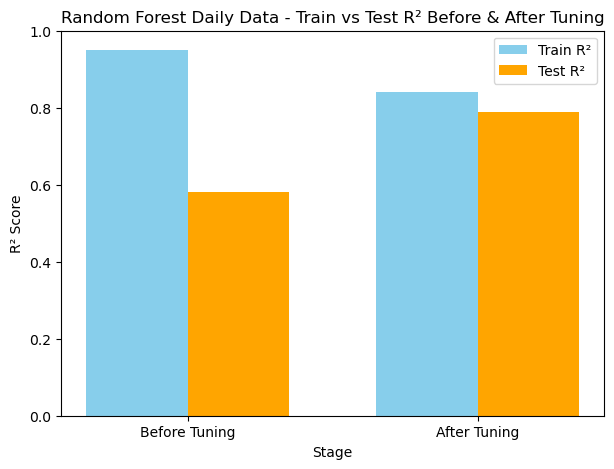

In [38]:
# Models / Stages
stages = ['Before Tuning', 'After Tuning']

# Train and Test R² values
train_r2 = [0.95, 0.84]  
test_r2  = [0.58, 0.79]

x = np.arange(len(stages))
bar_width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x, train_r2, width=bar_width, label='Train R²', color='skyblue')
plt.bar(x + bar_width, test_r2, width=bar_width, label='Test R²', color='orange')

plt.xlabel("Stage")
plt.ylabel("R² Score")
plt.title("Random Forest Daily Data - Train vs Test R² Before & After Tuning")
plt.xticks(x + bar_width/2, stages)
plt.ylim(0,1)
plt.legend()
plt.show()

In [67]:
last_row = X_test_hr.iloc[-1:].copy()


In [68]:
predictions = []

start_hour =4 

for i in range(1, 7):
    next_hour = (start_hour + i) % 24
    last_row['hr'] = next_hour

    pred = rf_hour.predict(last_row)[0]
    predictions.append([next_hour, int(round(pred))])


In [69]:
pred_df = pd.DataFrame(
    predictions,
    columns=['Hour', 'Predicted_Count']
)

pred_df



,Hour,Predicted_Count
0,5,30
1,6,121
2,7,364
3,8,599
4,9,286
5,10,141


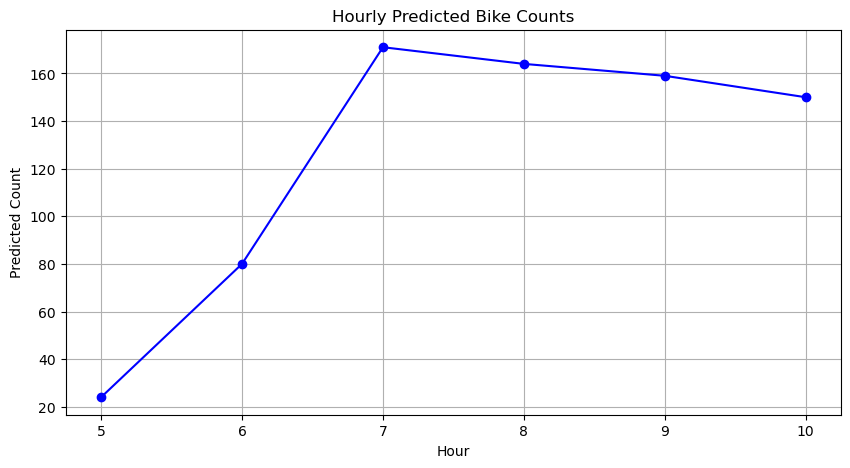

In [86]:

predicted_counts_hr = [24, 80, 171, 164, 159, 150]  
hours = [5, 6, 7, 8, 9, 10] 
plt.figure(figsize=(10,5))
plt.plot(hr_pred_df['Hour'], hr_pred_df['Predicted_Count'], marker='o', color='blue')
plt.title("Hourly Predicted Bike Counts")
plt.xlabel("Hour")
plt.ylabel("Predicted Count")
plt.xticks(hr_pred_df['Hour'])  
plt.grid(True)
plt.show()


In [70]:
rf_day

features = ['year', 'month', 'day', 'weekday', 'temp', 'hum', 'windspeed']


In [71]:
day['year'] = day['dteday'].dt.year
day['month'] = day['dteday'].dt.month
day['day'] = day['dteday'].dt.day
day['weekday'] = day['dteday'].dt.weekday

last_day = day.iloc[-1].copy()


In [74]:
future_days = []

last_row = X_test.iloc[-1]
current_date = day.loc[X_test.index[-1], 'dteday']

for i in range(1, 7):
    next_date = current_date + pd.Timedelta(days=1)

    input_row = pd.DataFrame([{
        'year': next_date.year,
        'month': next_date.month,
        'day': next_date.day,
        'weekday': next_date.weekday(),
        'temp': last_row['temp'] * (1 + 0.02*i),     # ⬅ increased
        'hum': last_row['hum'] * (1 - 0.01*i),       # ⬅ increased
        'windspeed': last_row['windspeed'] * (1 + 0.005*i)
    }])

    pred = rf_day.predict(input_row.values)[0]

    future_days.append({
        'Date': next_date.date(),
        'Predicted_Count': int(round(pred))
    })

    current_date = next_date

       


In [75]:

day_predictions = pd.DataFrame(future_days)
day_predictions


,Date,Predicted_Count
0,2011-05-17,6758
1,2011-05-18,6843
2,2011-05-19,6930
3,2011-05-20,6942
4,2011-05-21,6956
5,2011-05-22,7016


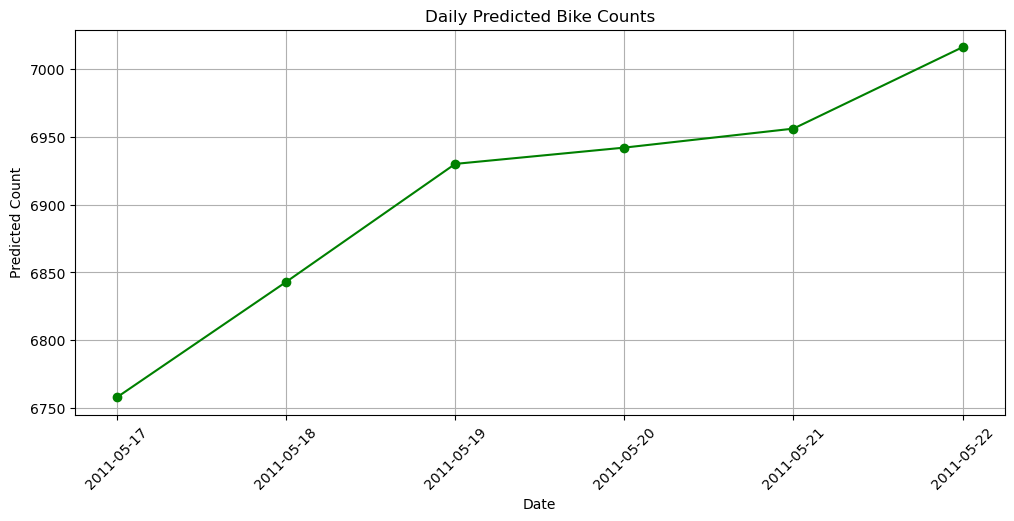

In [85]:

predicted_counts = [6758, 6843, 6930, 6942, 6956, 7016] 
dates = pd.date_range(start='2011-05-17', periods=len(predicted_counts))  
plt.figure(figsize=(12,5))
plt.plot(day_pred_df['Date'], day_pred_df['Predicted_Count'], marker='o', color='green')
plt.title("Daily Predicted Bike Counts")
plt.xlabel("Date")
plt.ylabel("Predicted Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()